In [374]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# prevent different random data every run
np.random.seed(42)

In [375]:
phy_marks = np.random.randint(0, 100, size=(10000,))
chem_marks = np.random.randint(0, 100, size=(10000,))
math_marks = np.random.randint(0, 100, size=(10000,))
com_marks = np.random.randint(0, 100, size=(10000,))
eng_marks = np.random.randint(0, 100, size=(10000,))


# compact each books
subjects = np.asarray([phy_marks, chem_marks, math_marks, com_marks, eng_marks], dtype=float)
m = subjects.shape[0] # total no. of features


# CALCULATES:
# total marks
total_marks = np.sum(subjects, axis=0)

# percentage %
per = np.round(total_marks / (100 * m) * 100, 2)

# GPA
gpa = np.round(per / 100 * 4, 2)


# final result
final_results = np.all(subjects >= 35, axis=0)
results = np.where(final_results, "PASS", "FAIL")

# Grades: [A+: 90+, A: 80+, B+: 70+, B: 60+, C+: 50+, C: 35+, D: Fail]
conditions = [
    per >= 90,
    per >= 80,
    per >= 70,
    per >= 60,
    per >= 50,
    per >= 35
]

grades = ['A+', 'A', 'B+', 'B', 'C+', 'C']
final_grade = np.select(conditions, grades, default='NG')

std_df = pd.DataFrame({
    "Physics":phy_marks, 
    "Chemistry":chem_marks,
    "Math":math_marks,
    "Computer":com_marks,
    "English":eng_marks,
    "Total Marks": total_marks,
    "Percentages %":per,
    "Grades":final_grade,
    "GPA":gpa,
    "Final Results":results
})  


# Data cleaning

In [376]:
std_df.rename(columns={
    "Physics":"phy", 
    "Chemistry":"chem", 
    "Computer":"com",
    "Math":"math", 
    "English":"eng",
    "Total Marks":"total_marks"
    }, inplace=True
)
std_df.head()

,phy,chem,math,com,eng,total_marks,Percentages %,Grades,GPA,Final Results
0,51,37,68,32,78,266.0,53.2,C+,2.13,FAIL
1,92,37,52,77,84,342.0,68.4,B,2.74,PASS
2,14,52,95,27,63,251.0,50.2,C+,2.01,FAIL
3,71,92,51,17,22,253.0,50.6,C+,2.02,FAIL
4,60,99,87,54,84,384.0,76.8,B+,3.07,PASS


# Analyze data

In [377]:
# total no. of students
total_std = len(std_df)

# count grades
grade_order = ["A+", "A", "B+", "B", "C+", "C", "NG"]
total_grades = std_df["Grades"].value_counts().reindex(grade_order, fill_value=0)
grade_percentage = total_grades / total_std * 100
labels = [f"{g:.2f}%" for g in grade_percentage]


# total pass and fail
result_orders = ["FAIL", "PASS"]
count_results = std_df["Final Results"].value_counts().reindex(result_orders, fill_value=0)


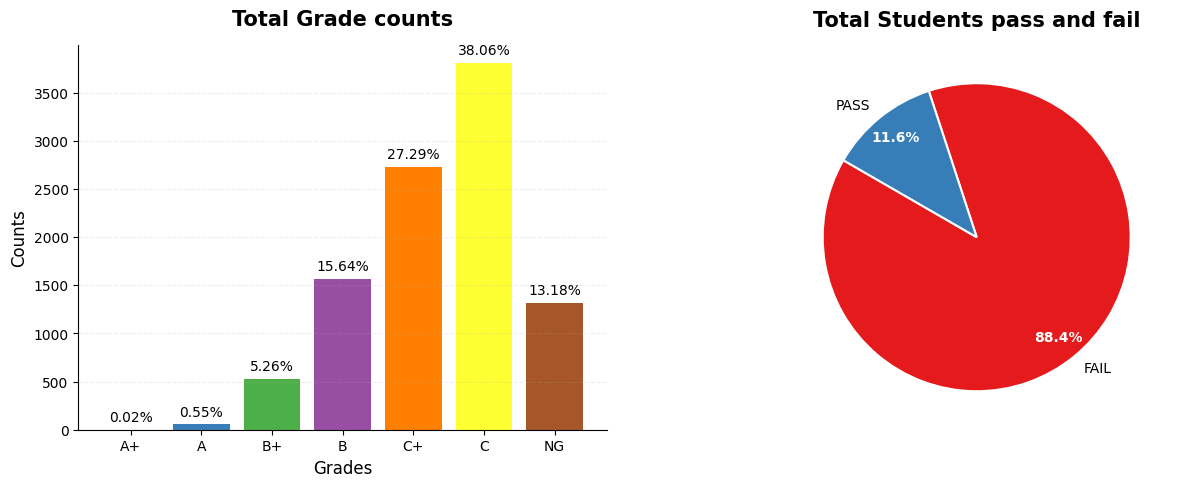

In [386]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax1 = axes[0]
ax2 = axes[1]

# Bar chart(Total Grade counts)
colors = plt.cm.Set1.colors

# plot
bars = ax1.bar(grade_order, total_grades, color=colors[:len(grade_order)])

# add style
ax1.set_title("Total Grade counts", fontsize=15, fontweight="bold", pad=14)
ax1.set_xlabel("Grades", fontsize=12)
ax1.set_ylabel("Counts", fontsize=12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", linestyle="--", alpha=0.2)
ax1.bar_label(bars, labels=labels, padding=4, fontsize=10)



# Pie chart(Total pass and fail)
weights, texts, autotexts = ax2.pie(
    count_results,
    labels=result_orders,
    autopct="%1.1f%%",
    colors=colors[: len(result_orders)],
    startangle=150,
    pctdistance=0.84,
    wedgeprops={"linewidth":1.5, "edgecolor":"white"}
    
)

for text in autotexts:
    text.set_fontsize(10)
    text.set_color("white")
    text.set_fontweight("bold")

ax2.set_title("Total Students pass and fail", fontsize=15, fontweight="bold", pad=13)

# save image
name_img = "grade.png"
plt.savefig(name_img, dpi=150, bbox_inches="tight")

plt.show()